In [1]:
%load_ext autoreload
%autoreload 2

from helper import *
import matplotlib.pyplot as plt
import numpy as np

0.1 def mexican_hat_1d in helper.py

0.2 Plot Mexican-hat

In [2]:
M = 100
x = np.linspace(-M/2, M/2, M, endpoint=False)

W = mexican_hat_1d(x, A_exc=0.3, sigma_exc=5.0, A_inh=0.2, sigma_inh=10.0)

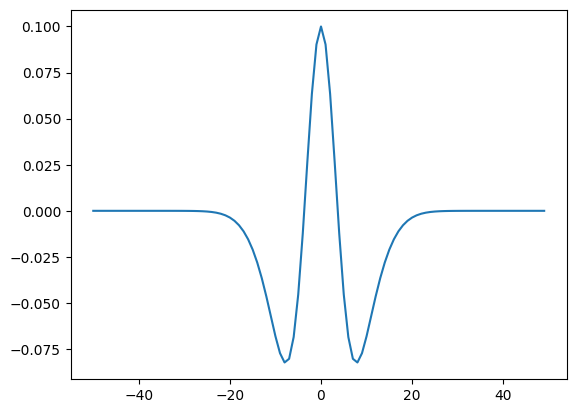

In [3]:
plt.plot(x, W)

0.3 The Mexican-hat kernel represents local excitation and broader surround inhibition. Nearby neurons excite each other because the excitatory Gaussian is narrower and stronger near zero distance. More distant neurons inhibit each other because the inhibitory Gaussian has a wider spatial spread. Biologically, this captures the idea of local recurrent excitation combined with longer-range inhibition, which can stabilize localized activity bumps and create competition between different regions of the neural sheet.

0.4 Euler method

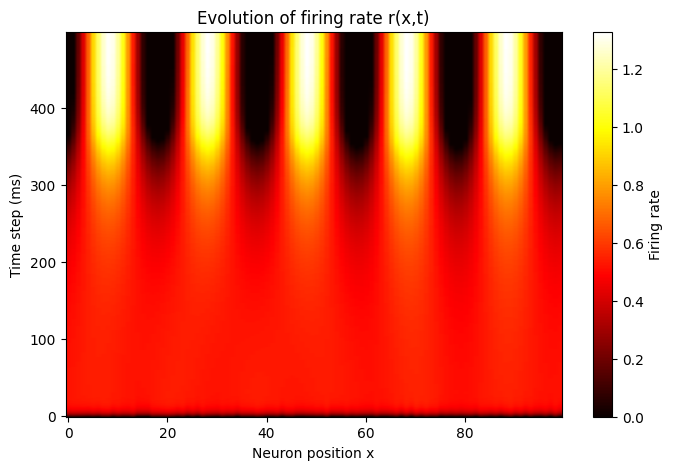

In [4]:
from scipy.ndimage import convolve1d

# parameters
M = 100
dt = 1.0
tau = 10.0
T = 500        
B = 1.0

A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0

x = np.linspace(-M/2, M/2, M, endpoint=False)

W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)

np.random.seed(0)
s = np.random.uniform(0, 0.1, size=M)

r_history = np.zeros((T, M))

for t in range(T):
    r = relu(s)
    r_history[t] = r

    # periodic convolution
    I_rec = convolve1d(r, W, mode='wrap')

    # Euler update: tau ds/dt = -s + I_rec + B
    dsdt = (-s + I_rec + B) / tau
    s = s + dt * dsdt

plt.figure(figsize=(8, 5))
plt.imshow(r_history, aspect='auto', origin='lower', cmap='hot')
plt.colorbar(label='Firing rate')
plt.xlabel('Neuron position x')
plt.ylabel('Time step (ms)')
plt.title('Evolution of firing rate r(x,t)')
plt.show()

0.5 three-seed plot

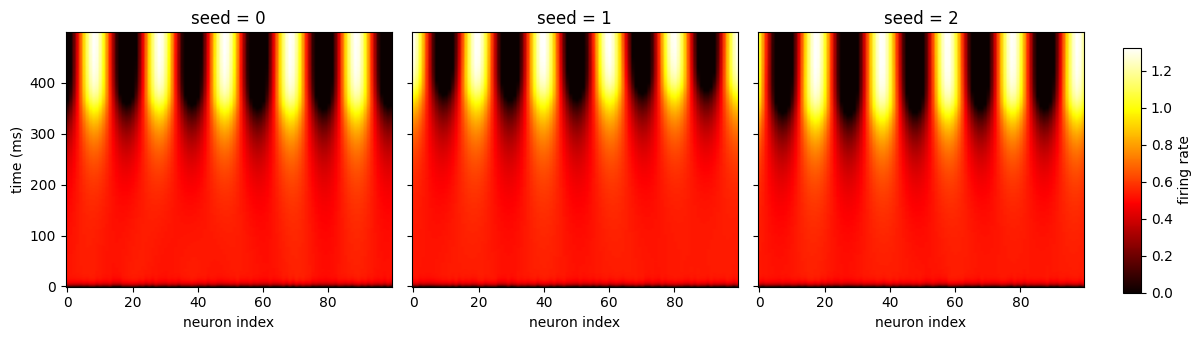

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, seed in zip(axes, seeds):
    np.random.seed(seed)
    s = np.random.uniform(0, 0.1, size=M)
    r_history = np.zeros((T, M))

    for t in range(T):
        r = relu(s)
        r_history[t] = r
        I_rec = convolve1d(r, W, mode="wrap")
        dsdt = (-s + I_rec + B) / tau
        s = s + dt * dsdt

    im = ax.imshow(r_history, aspect="auto", origin="lower", cmap="hot")
    ax.set_title(f"seed = {seed}")
    ax.set_xlabel("neuron index")

axes[0].set_ylabel("time (ms)")

plt.tight_layout(rect=[0, 0, 0.92, 1])

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="firing rate")

plt.show()

Across three random seeds, the network consistently develops stable spatially periodic bumps. The exact phase/location of the bumps depends on the random initialization, because the ring has translation symmetry and no preferred absolute position. However, the qualitative behavior is robust: the activity evolves from random initial potentials into a stable bump pattern.